In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures
import pandas as pd
from tqdm import tqdm
from scipy.optimize import minimize, basinhopping

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [2]:
Main.eval('using Distributed')
Main.eval('addprocs(7)') 

array([2, 3, 4, 5, 6, 7, 8], dtype=int64)

In [ ]:
Main.eval("""
    @everywhere begin
        using Distributed
        using DelimitedFiles      
        df_LO = readdlm("fixed order/EECLO.csv", ',')
        df_NLO = readdlm("fixed order/EECNLO.csv", ',')
        df_NNLO = readdlm("fixed order/EECNNLO.csv", ',')
    end
""")

Main.include("setting.jl")
Main.include("strong coupling\\constants.jl")
Main.include("strong coupling\\alpha_s.jl")

Main.include("fixed order\\perturbative EEC.jl")
Main.include("fixed order\\FO.jl")
Main.include("fixed order\\non-singular.jl")
Main.include("fixed order\\analytic.jl")

Main.include("Σb.jl")
Main.include("cross section.jl")
Main.include("NP.jl")
Main.include("parallel/fit.jl")

<PyCall.jlwrap model>

In [4]:
zmax=0.25
np.arccos(1-2*zmax)*180/np.pi

60.00000000000001

In [5]:
χ_fitted_lower = 0.0
χ_fitted_upper = 60
χ_plot_lower = 0.2
χ_plot_upper = 70

In [6]:
optimal_params = [0.118,0.835,2.776,1.191,1.376]

In [7]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [8]:
error_type = "both"

df_NNLO = pd.read_csv("fixed order/EECNNLO.csv",header=None)

def fixed_error_func(angle: float, df: pd.DataFrame) -> float:
    angles = df.iloc[:, 0]      
    errors = df.iloc[:, 2]       
    
    pos = np.abs(angles.values - angle).argmin()
    return float(errors.iloc[pos])

In [10]:
#-------------------------------------------------------------------
dataset_names = ["SLD","TOPAZ_595","TOPAZ_533",
                "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

df_original = {}

for name in dataset_names:
    file_path = f"data/{name}.csv"
    df0 = pd.read_csv(file_path)
    
    χ = df0["CHI"]
    EEC = df0["EEC"]
    ERROR = df0["ERROR"]
    Q = df0["Q"]
    BinSize = df0["BinSize"]

    print(Q[0])

    if error_type == "both":
        
        Main.αs_Z = 0.118        
        αs = Main.alpha_s_func(Q[0])
        a = αs/(2*np.pi)

        fixed_error=[]
        for angle in χ:
            value = (a**3)*fixed_error_func(angle=angle, df=df_NNLO)
            fixed_error.append(value)
        ERROR = np.sqrt(df0["ERROR"]**2 + np.array(fixed_error)**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR, "Q": Q, "BinSize": BinSize})
    df_original[name] = df1

91.2
59.5
53.3
43.5
34.8
29.0
29.0


In [11]:
cut_list = {}
cut_list["sqrtz"] = [0,1/2]

In [12]:
df_truncated = {}

χ = {}
EEC = {}
ERROR = {}
Q = {}
BinSize = {}

df = df_original
for name in dataset_names:
    sqrtz_list = np.sqrt((1-np.cos(df[name]["CHI"]*np.pi/180))/2)
    kt_list = sqrtz_list*df[name]["Q"]

    if "sqrtz" in cut_list:
        sqrtz_lower, sqrtz_upper = cut_list["sqrtz"]
        df_truncated[name] = df[name][(sqrtz_list <= sqrtz_upper) & (sqrtz_list >= sqrtz_lower)]

    if "kt" in cut_list:
        χ_lower, χ_upper = cut_list["kt"]
        df_truncated[name] = df[name][(kt_list <= kt_upper) & (kt_list >= kt_lower)]

    if "χ" in cut_list:
        kt_lower, kt_upper = cut_list["kt"]
        df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]
    
    χ[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])
    Q[name] = np.array(df_truncated[name]["Q"])
    BinSize[name] = np.array(df_truncated[name]["BinSize"])

#display(df_truncated)
for name in dataset_names:
    display(len(df_truncated[name]))

16

16

16

16

16

16

16

In [13]:
def DELTA_func(ylist,PRED):
    l = len(ylist)
    theory = np.zeros(l)
    for i in range(l):
        simpson = 1/12*(PRED[0][i] + 4*PRED[1][i] + 2*PRED[2][i] + 4*PRED[3][i] + PRED[4][i])
        theory[i] = np.nan_to_num(simpson,nan=0.0)
    return theory - ylist

def CHI2_func(DELTA,ERROR):
    chi_squared = np.sum(np.square(DELTA/ERROR))
    return chi_squared

In [17]:
def objective(params, df):

    N = 5
    
    chi2 = 0
    N_total = 0
    
    αs = params[0]
    params_noαs = params[1:]

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    dataset_names = df.keys()

    for name in dataset_names:
        xlist={}
        xlist_mid = np.array(df[name]["CHI"])
        binsize = np.array(df[name]["BinSize"]) 
        for i in range(N):
            xlist[i]=xlist_mid-binsize/2+i*binsize/(N-1)

        ylist=np.array(df[name]["EEC"])
        ERROR_list=np.array(df[name]["ERROR"])

        data_size = len(xlist_mid)
        N_total = N_total + data_size

        PRED={}

        parameters = params_noαs
        for quartile in range(N):
            PRED[quartile] = Main.model(xlist=xlist[quartile], Qlist=np.array(df[name]["Q"]))                
        DELTA =  DELTA_func(ylist,PRED)                       

        chi_square = CHI2_func(DELTA,ERROR_list)
        chi2 = chi2 + chi_square

    return chi2/N_total

In [18]:
Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

Test

In [19]:
objective(optimal_params, df_truncated)

1.237423860864541

Import replicas 

In [20]:
result_set = {}
accuracies = ["4params_fit_1","4params_scan_1"]
for XLL in accuracies:
    result_set[XLL] = pd.read_csv("result/"+XLL+".csv")

In [21]:
import ast
def convert_to_list(string):
    corrected_string = string.replace("      ", ",")
    corrected_string = corrected_string.replace("     ", ",")
    corrected_string = corrected_string.replace("    ", ",") 
    corrected_string = corrected_string.replace("   ", ",") 
    corrected_string = corrected_string.replace("  ", ",")    
    corrected_string = corrected_string.replace(" ", ",")
    l=len(corrected_string)
    new_string=""
    for i in range(1,l-1):
        if (corrected_string[i]=="," and (corrected_string[i-1]=="[" or corrected_string[i+1]=="]")):
            new_string = new_string
        else:
            new_string = new_string + corrected_string[i]

    new_string = new_string + "]"
    new_string = "[" + new_string

    return ast.literal_eval(new_string)

αs_set = {}
Ω1_set = {}
a_set = {}

for XLL in accuracies:
    results_df = result_set[XLL]
    αs_set[XLL] = results_df['αs'].to_numpy()
    params = results_df['params'].apply(convert_to_list)
    params = np.array(params.to_list())

    rows = len(params)
    cols = len(params[0])
    a_list = {}

    for i in range(cols):
        a_list[i] = params[:,i]
            
    a_set[XLL] = a_list

    #print(a_list)

In [22]:
#print(N_params)
#print(N_replicas)
params_replicas={}
for XLL in accuracies:
    N_params = len(a_set[XLL])
    N_replicas = len(a_set[XLL][0])
    params_reps = []
    for i in range(N_replicas):
        params = []
        for j in range(N_params):
            value = a_set[XLL][j][i]
            params.append(value)
        params_reps.append(params)
    params_replicas[XLL]=params_reps

In [23]:
display(params_replicas)
#display(αs_set)

{'4params_fit_1': [[0.83672, 2.75016, 1.18541, 1.35222],
  [0.84731, 2.74672, 1.15792, 1.27776],
  [0.83273, 2.73927, 1.20356, 1.48669],
  [0.83082, 2.77594, 1.19864, 1.42356],
  [0.83295, 2.72555, 1.18489, 1.39264],
  [0.83522, 2.7889, 1.19546, 1.36539],
  [0.83285, 2.77863, 1.19679, 1.35064],
  [0.83795, 2.78859, 1.18546, 1.28518],
  [0.82849, 2.78412, 1.19123, 1.38605],
  [0.82978, 2.87746, 1.19787, 1.34304],
  [0.83982, 2.7555, 1.18669, 1.32278],
  [0.83755, 2.80712, 1.20542, 1.36038],
  [0.84358, 2.76139, 1.18587, 1.28016],
  [0.83191, 2.77531, 1.2034, 1.43289],
  [0.83283, 2.77359, 1.20735, 1.41127],
  [0.83425, 2.80825, 1.19749, 1.387],
  [0.8293, 2.7544, 1.19374, 1.36242],
  [0.83084, 2.72254, 1.18143, 1.40518],
  [0.83783, 2.7092, 1.18459, 1.3635],
  [0.83176, 2.79668, 1.2008, 1.38391],
  [0.83122, 2.78482, 1.19574, 1.40077],
  [0.82803, 2.82354, 1.20004, 1.39194],
  [0.82663, 2.82976, 1.213, 1.45382],
  [0.8363, 2.77069, 1.18839, 1.37037],
  [0.83912, 2.78242, 1.19289, 1.3386

Calculate bands

In [25]:
N_points=200
xlist = np.linspace(χ_plot_lower, χ_plot_upper, N_points, endpoint=True)
length=len(xlist)

EEC_replicas = {}
for XLL in accuracies:
    i=0
    EEC_reps = []
    for params in tqdm(params_replicas[XLL]):
        #print(params) 
        EEC = {}
        for name in dataset_names:

            Main.eval(f'@everywhere αs_Z = {αs_set[XLL][i]}')
            Main.eval(f'@everywhere params = {params}') 
            Main.eval(f'@everywhere μJ_ratio = 1.0')
            Main.eval(f'@everywhere μH_ratio = 1.0')
            Main.eval(f'@everywhere μren_ratio = 1.0')     
                   
            Qlist = Q_list[name]*np.ones(N_points)
            EEC[name] = Main.model(Qlist=Qlist, xlist=xlist)  

        EEC_reps.append(EEC)
        i = i+1
    EEC_replicas[XLL] = EEC_reps

100%|██████████| 200/200 [00:58<00:00,  3.42it/s]


In [26]:
EEC_replicas

{'4params_fit_1': [{'SLD': array([0.16550985, 0.44842105, 0.7116407 , 0.94529378, 1.14273277,
          1.30079749, 1.41950047, 1.50133182, 1.55041461, 1.57170234,
          1.57033448, 1.55118995, 1.51862591, 1.47636187, 1.42746335,
          1.37438525, 1.31904505, 1.26290602, 1.20705854, 1.15229366,
          1.09916653, 1.04804929, 0.99917415, 0.9526678 , 0.90857863,
          0.86689808, 0.8275771 , 0.79053874, 0.75568767, 0.72291736,
          0.69211549, 0.66316783, 0.63596093, 0.61038413, 0.58633096,
          0.56369982, 0.54239466, 0.52232504, 0.50340625, 0.48555927,
          0.46871054, 0.45279175, 0.43773949, 0.42349504, 0.41000407,
          0.39721634, 0.38762363, 0.37652614, 0.36592486, 0.35557943,
          0.34562283, 0.33607426, 0.3269085 , 0.31810217, 0.31001904,
          0.30242972, 0.29513924, 0.28813018, 0.28138637, 0.27480034,
          0.26837618, 0.26217507, 0.25618481, 0.25039403, 0.24499576,
          0.24005459, 0.23528299, 0.23067227, 0.22621427, 0.221744

In [27]:
Main.eval('rmprocs(workers())')

<PyCall.jlwrap Task (runnable) @0x0000023e992cf270>

In [28]:
EEC_upper = {}
EEC_lower = {}

for XLL in accuracies:
    EEC_up = {}
    EEC_low = {}
    for name in dataset_names: 
        upper_band = []
        lower_band = []
        for i in range(length):
            compare_list = []
            for j in range(N_replicas):
                value = EEC_replicas[XLL][j][name][i]
                compare_list.append(value)
            upper_EEC = np.percentile(compare_list,84)
            upper_band.append(upper_EEC)
            lower_EEC =np.percentile(compare_list,16)
            lower_band.append(lower_EEC)
        EEC_up[name]=upper_band
        EEC_low[name]=lower_band    
    EEC_upper[XLL] = EEC_up
    EEC_lower[XLL] = EEC_low 

import json
with open("plot_data/4params_fit_1_upper.json", "w") as file:
    json.dump(EEC_upper, file)
with open("plot_data/4params_fit_1_lower.json", "w") as file:
    json.dump(EEC_lower, file)

In [29]:
import json
EEC_upper = {}
EEC_lower = {}

with open("plot_data/4params_fit_1_upper.json", "r") as file:
    EEC_upper = json.load(file)
with open("plot_data/4params_fit_1_lower.json", "r") as file:
    EEC_lower = json.load(file)

for XLL in accuracies:
    display(np.array(EEC_upper[XLL]["SLD"])-np.array(EEC_lower[XLL]["SLD"]))

array([0.00651268, 0.01712836, 0.02579348, 0.0315444 , 0.03589214,
       0.03581778, 0.03367583, 0.03000544, 0.02700661, 0.02382539,
       0.02186657, 0.01928635, 0.01796434, 0.01574372, 0.01419932,
       0.01298581, 0.01249998, 0.01135406, 0.01037173, 0.0094351 ,
       0.00850467, 0.00846454, 0.00837994, 0.00817941, 0.00825334,
       0.00793781, 0.00793813, 0.0078601 , 0.00763348, 0.00711015,
       0.00701277, 0.00722787, 0.0072826 , 0.0073429 , 0.0071525 ,
       0.00704027, 0.00692061, 0.00697696, 0.0068812 , 0.00675016,
       0.0067057 , 0.00661875, 0.00645471, 0.00628023, 0.0061031 ,
       0.0059997 , 0.00568417, 0.00567761, 0.00565879, 0.00553783,
       0.00539443, 0.00528105, 0.005218  , 0.00514717, 0.00504653,
       0.0049365 , 0.00482127, 0.00471855, 0.00463893, 0.00456158,
       0.00447144, 0.00436305, 0.00425421, 0.0041507 , 0.00402471,
       0.00386095, 0.00372812, 0.00363735, 0.00354414, 0.00346537,
       0.00341311, 0.00334897, 0.00331061, 0.00327431, 0.00323

array([0.02295681, 0.06114127, 0.09361779, 0.11799401, 0.13411166,
       0.14192989, 0.14070712, 0.13582326, 0.12730226, 0.11513296,
       0.0990053 , 0.08548632, 0.07125131, 0.05841225, 0.04800455,
       0.03992213, 0.0318043 , 0.02750281, 0.02189926, 0.01972005,
       0.01887909, 0.01826576, 0.0167754 , 0.01656696, 0.01706539,
       0.0172207 , 0.01753317, 0.01732889, 0.01664705, 0.01631542,
       0.0162046 , 0.01614715, 0.01579895, 0.01542333, 0.01503371,
       0.01475853, 0.01447978, 0.01419277, 0.01386738, 0.01357386,
       0.01324081, 0.01289593, 0.01251728, 0.01216643, 0.01182548,
       0.01149981, 0.01122632, 0.01092421, 0.01062616, 0.01032645,
       0.01001313, 0.00971471, 0.00945099, 0.00919233, 0.00894373,
       0.00870297, 0.00846813, 0.00823936, 0.00801668, 0.00779808,
       0.00758291, 0.00737418, 0.00717175, 0.00697543, 0.00678738,
       0.00660824, 0.00643477, 0.00626678, 0.00610408, 0.00594437,
       0.00578445, 0.00562936, 0.00547891, 0.00533293, 0.00519

Central Curve

In [31]:
N_points=200
xlist = np.linspace(χ_plot_lower, χ_plot_upper, N_points, endpoint=True)
length=len(xlist)

αs=optimal_params[0]
params_noαs = optimal_params[1:]

central={}

for name in dataset_names:

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    Qlist = Q_list[name]*np.ones(N_points)
    central[name] = Main.model(Qlist=Qlist, xlist=xlist)  

In [32]:
display(central)

{'SLD': array([0.16362854, 0.4434687 , 0.70420793, 0.93620527, 1.13289049,
        1.29103555, 1.41048366, 1.4935096 , 1.54402369, 1.56680144,
        1.56685298, 1.54897662, 1.51748959, 1.4761012 , 1.42788608,
        1.37531905, 1.32034224, 1.26444432, 1.20873956, 1.15404025,
        1.10091971, 1.04976517, 1.00082109, 0.95422397, 0.91002989,
        0.86823623, 0.82879845, 0.79164296, 0.75667689, 0.72379548,
        0.69288757, 0.66383968, 0.63653881, 0.61087447, 0.58674022,
        0.56403433, 0.54266053, 0.52252811, 0.50355207, 0.48565306,
        0.46875715, 0.45279572, 0.43770502, 0.42342602, 0.40990409,
        0.39708869, 0.38751596, 0.37640398, 0.36578939, 0.35542802,
        0.34545558, 0.335892  , 0.32671196, 0.31789198, 0.30980251,
        0.30221043, 0.29491758, 0.28790651, 0.28116097, 0.27457181,
        0.2681434 , 0.26193819, 0.25594394, 0.25014925, 0.24475069,
        0.23981415, 0.23504717, 0.23044105, 0.22598761, 0.22151926,
        0.21679876, 0.21220933, 0.2077446

Calculate data

In [33]:
df = df_original
df_plot={}
for name in dataset_names:
    df_plot[name] = df[name][(df[name]["CHI"] <= χ_plot_upper) & (df[name]["CHI"] >= χ_plot_lower)]

In [35]:
αs=optimal_params[0]
params_noαs = optimal_params[1:]
#print(params_noαs)

v={}
non_singular = {}
central_data={}

for name in dataset_names:

    Main.eval(f'@everywhere αs_Z = {αs}')
    Main.eval(f'@everywhere params = {params_noαs}') 
    Main.eval(f'@everywhere μJ_ratio = 1.0')
    Main.eval(f'@everywhere μH_ratio = 1.0')
    Main.eval(f'@everywhere μren_ratio = 1.0') 

    x_array = np.array(df_plot[name]["CHI"])
    Q_array = np.array(df_plot[name]["Q"])
    central_data[name] = Main.model(Qlist=Q_array, xlist=x_array)  

In [36]:
display(central_data["SLD"])

array([1.38472932, 0.86463873, 0.55635422, 0.38952505, 0.29577998,
       0.23437759, 0.19274775, 0.16445609, 0.14353507, 0.12767454,
       0.11542329, 0.10781586, 0.09892724, 0.09409496, 0.08921308,
       0.08573207, 0.08317695, 0.08146695])

In [37]:
accuracy = ["4params_fit_1","4params_scan_1"]

df_fitted={}
central_fitted={}
for name in dataset_names:
    df_fitted[name] = df[name][(df[name]["CHI"] >= χ_fitted_lower) & (df[name]["CHI"] <= χ_fitted_upper)]
    length = len(df_fitted[name]["CHI"])
    central_fitted[name] = central_data[name][0:length]

#df_fitted["OPAL_new"] = df["OPAL_new"][(df["OPAL_new"]["CHI"] >= χ_lower) & (df["OPAL_new"]["CHI"] <= χ_upper)]
#central_fitted["OPAL_new"] = central_data["OPAL_new"][30:60]

name_set = {}
name_set["SLD"]       = "SLD"
name_set["OPAL"]      = "OPAL_old"
name_set["OPAL_new"]  = "OPAL"
name_set["DELPHI"]    = "DELPHI"
name_set["TOPAZ_595"] = "TOPAZ"
name_set["TOPAZ_533"] = "TOPAZ"
name_set["TASSO_435"] = "TASSO"
name_set["TASSO_348"] = "TASSO"
name_set["MARKII"]    = "MARKII"
name_set["MAC"]       = "MAC"

In [38]:
df_fitted

{'SLD':      CHI     EEC     ERROR     Q  BinSize
 0    5.4  1.3160  0.032808  91.2      3.6
 1    9.0  0.8740  0.020608  91.2      3.6
 2   12.6  0.5980  0.019352  91.2      3.6
 3   16.2  0.4250  0.011290  91.2      3.6
 4   19.8  0.3100  0.014205  91.2      3.6
 5   23.4  0.2410  0.005242  91.2      3.6
 6   27.0  0.1990  0.005225  91.2      3.6
 7   30.6  0.1680  0.006162  91.2      3.6
 8   34.2  0.1460  0.005189  91.2      3.6
 9   37.8  0.1280  0.004224  91.2      3.6
 10  41.4  0.1180  0.003275  91.2      3.6
 11  45.0  0.1099  0.002845  91.2      3.6
 12  48.6  0.1014  0.003330  91.2      3.6
 13  52.2  0.0935  0.002915  91.2      3.6
 14  55.8  0.0901  0.002406  91.2      3.6
 15  59.4  0.0867  0.002547  91.2      3.6,
 'TOPAZ_595':      CHI    EEC     ERROR     Q  BinSize
 0    5.4  1.037  0.049740  59.5      3.6
 1    9.0  0.850  0.038184  59.5      3.6
 2   12.6  0.654  0.031306  59.5      3.6
 3   16.2  0.470  0.022938  59.5      3.6
 4   19.8  0.397  0.019971  59.5      

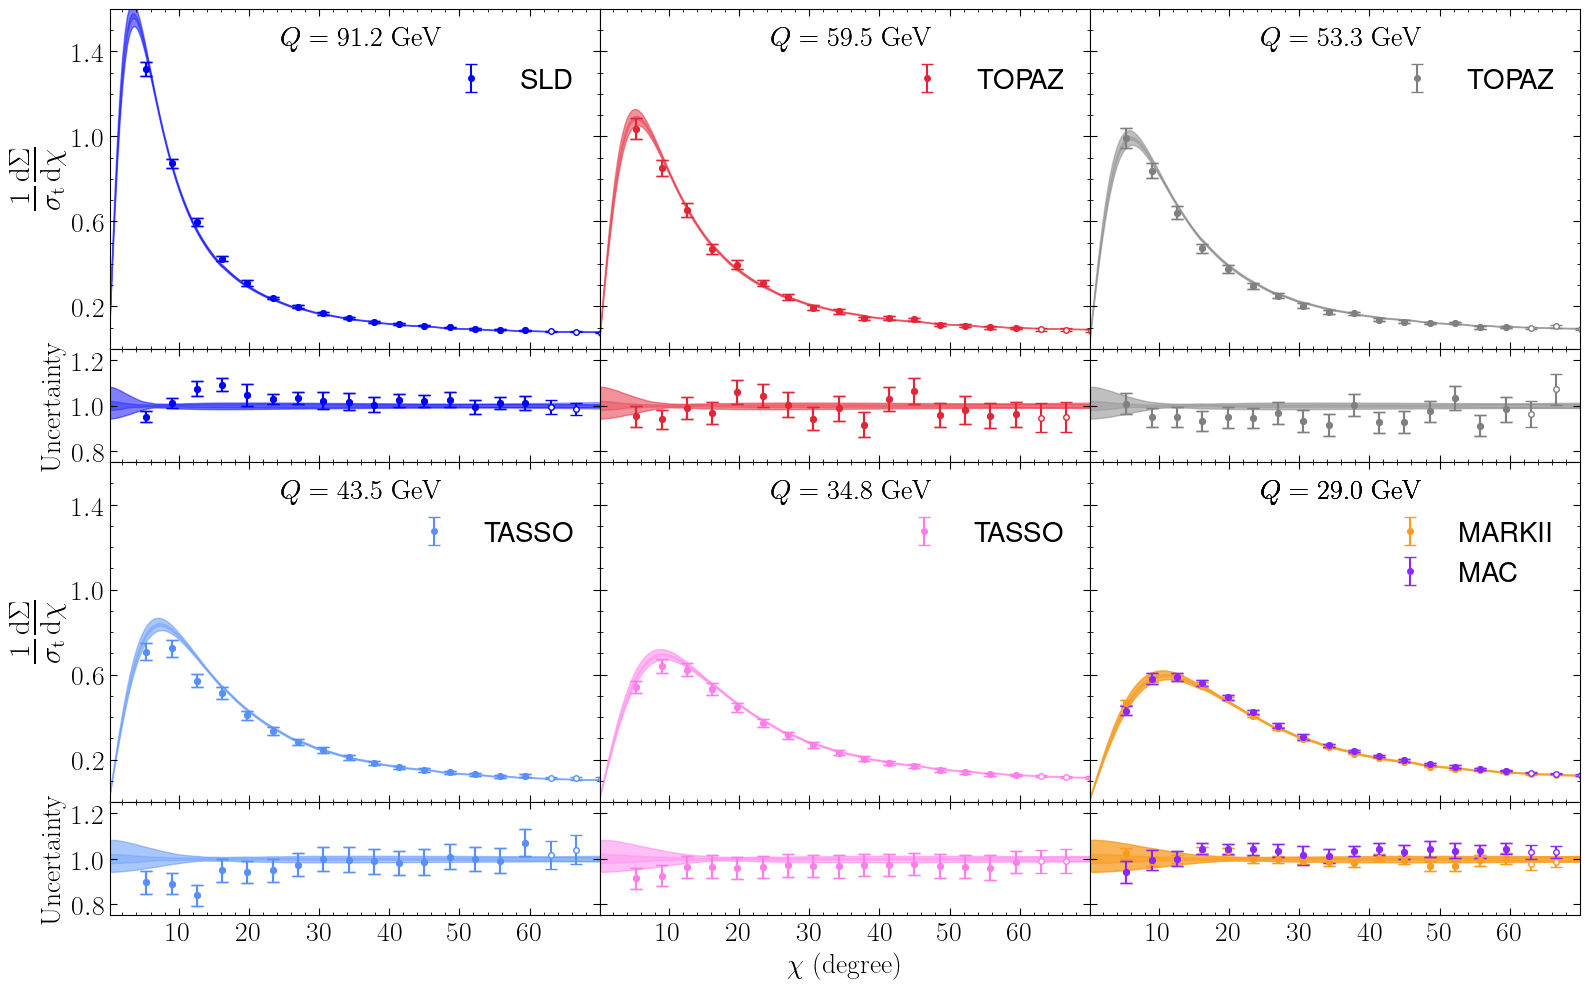

In [39]:
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex='col', gridspec_kw={'height_ratios': [3, 1, 3, 1]})
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes.ravel()

#Settings-----------------------------------------------------------------
sizeOfFont= 20
sizeOfTick = 20
sizeOfCap = 4
sizeOfMark = 4

props = dict(boxstyle='round', facecolor='white', alpha=0)

#color = ["blue","green","blue","green","blue","green","blue"]
#color = ["red","orange","gray","teal","blue","purple","black"]

blue=(87/255,144/255,252/255)
orange=(248/255,156/255,32/255)
red=(228/255,37/255,54/255)
purple1=(150/150,74/150,139/150)
gray=(156/161,156/161,161/161)
purple2=(122/221,33/221,221/221)
color = ["blue",red,"gray",blue,purple1,orange,purple2,"black"]

transparency=[0.3,0.5]

ax_list = [ax1,ax2,ax3,ax7,ax8,ax9]
ax_ratios = [ax4,ax5,ax6,ax10,ax11,ax12]

Q_set = [91.2,59.5,53.3,43.5,34.8,29.0]
names_band=["SLD","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII","MAC"]
#--------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
i=0
j=0
for Q in Q_set:
    for name in dataset_names:
        if Q_list[name]==Q:
            ax_list[i].errorbar(df[name]["CHI"], df[name]["EEC"], df[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_list[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"], df_fitted[name]["ERROR"], fmt='o', color=color[j], capsize=sizeOfCap,markersize=sizeOfMark,label=str(name_set[name]))
            j=j+1
    i=i+1

j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_list[i].fill_between(xlist, EEC_upper[XLL][name], EEC_lower[XLL][name], alpha=transparency[j], color=color[i])
                ax_list[i].text(0.35, 0.95, r"\rm $Q = \ $" + str(Q_list[name]) + " GeV", transform=ax_list[i].transAxes, fontsize=sizeOfFont, verticalalignment='top', bbox=props)
                #ax_list[i].plot(xlist*180/np.pi, EEC_upper[XLL][name], color=color[i], linewidth=1)
                #ax_list[i].plot(xlist*180/np.pi, EEC_lower[XLL][name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

for ax in ax_list:
    ax.minorticks_on()
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.legend(frameon = False,fontsize = sizeOfTick, bbox_to_anchor=(1.0, 0.9))
    ax.set_xlim(χ_plot_lower,χ_plot_upper)
    ax.set_xticks([10,20,30,40,50,60])
    ax.set_ylim(0.0,1.6)
    ax.set_yticks([0.2,0.6,1.0,1.4])

ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax8.set_yticklabels([])
ax9.set_yticklabels([])

ax1.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
ax7.set_ylabel(r"\rm $\frac{1}{\sigma_{\rm{t}}} \frac{\rm{d} \Sigma}{\rm{d} \chi}$",fontsize=1.5*sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

#--------------------------------------------------------------------------------------------------------------------------------------------------------------------
j=0
for XLL in accuracy:
    i=0
    for Q in Q_set:
        for name in names_band:
            if Q_list[name]==Q:
                ax_ratios[i].fill_between(xlist, EEC_upper[XLL][name]/central[name], EEC_lower[XLL][name]/central[name], alpha=transparency[j], color=color[i])
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_upper[XLL][name]/central[name], color=color[i], linewidth=1)
                #ax_ratios[i].plot(xlist*180/np.pi, EEC_lower[XLL][name]/central[name], color=color[i], linewidth=1)
        i=i+1
    j=j+1

i=0
j=0
for Q in Q_set:
    for name in names_band:
        if Q_list[name]==Q:
            ax_ratios[i].errorbar(df_plot[name]["CHI"], df_plot[name]["EEC"]/central_data[name], df_plot[name]["ERROR"]/central_data[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark, mfc='w')
            ax_ratios[i].errorbar(df_fitted[name]["CHI"], df_fitted[name]["EEC"]/central_fitted[name], df_fitted[name]["ERROR"]/central_fitted[name], fmt='o', color=color[j], capsize=sizeOfCap, markersize=sizeOfMark)
            j=j+1
    i=i+1

for ax in ax_ratios:
    ax.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)
    ax.set_xlim(χ_plot_lower,χ_plot_upper)
    ax.set_xticks([10,20,30,40,50,60])
    ax.set_ylim(0.75,1.25)
    ax.set_yticks([0.8,1.0,1.2])

ax5.set_yticklabels([])
ax6.set_yticklabels([])
ax11.set_yticklabels([])
ax12.set_yticklabels([])

ax4.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax10.set_ylabel(r"\rm $\rm{Uncertainty}$",fontsize=sizeOfFont)
ax11.set_xlabel(r"\rm $\chi \ (\rm{degree})$",fontsize=sizeOfFont)
#--------------------------------------------------------------------------------------------------------------------------------------------------------------------

plt.tight_layout()
plt.subplots_adjust(wspace=0,hspace=0)
plt.show()

fig.savefig('fit_bbstar.pdf')